In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape :", x_test.shape)

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.hist(y_train, bins=np.arange(11)-0.5)
plt.xticks(range(10), class_names, rotation=45)
plt.title("Class Distribution")
plt.show()

x_train = x_train.reshape(-1,784).astype("float32")/255.0
x_test = x_test.reshape(-1,784).astype("float32")/255.0

print("Flattened Shape:", x_train.shape)

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)
baseline_model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_history = baseline_model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

baseline_pred = np.argmax(
    baseline_model.predict(x_test),
    axis=1
)

baseline_acc = accuracy_score(y_test, baseline_pred)

print("\nBaseline Accuracy:", baseline_acc)


plt.plot(baseline_history.history["accuracy"])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.plot(baseline_history.history["val_accuracy"])
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.plot(baseline_history.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(baseline_history.history["val_loss"])
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


def create_model(neurons=128, learning_rate=0.001):

    model = Sequential([
        Dense(neurons, activation="relu", input_shape=(784,)),
        Dense(neurons//2, activation="relu"),
        Dense(10, activation="softmax")
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


keras_model = KerasClassifier(
    model=create_model,
    verbose=0
)

param_dist = {
    "model__neurons":[64,128,256,512],
    "model__learning_rate":[0.01,0.001,0.0005,0.0001],
    "epochs":[5,10,15],
    "batch_size":[16,32,64]
}

random_search = RandomizedSearchCV(
    estimator=keras_model,
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

print("\nRunning Randomized Search...\n")

random_search.fit(
    x_train,
    y_train
)

print("\nBest Parameters")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy")
print(random_search.best_score_)

best_model = random_search.best_estimator_


optimized_pred = best_model.predict(x_test)

optimized_acc = accuracy_score(
    y_test,
    optimized_pred
)

optimized_precision = precision_score(
    y_test,
    optimized_pred,
    average="weighted"
)

optimized_recall = recall_score(
    y_test,
    optimized_pred,
    average="weighted"
)

optimized_f1 = f1_score(
    y_test,
    optimized_pred,
    average="weighted"
)

print("\nOptimized Accuracy:", optimized_acc)
print("Precision:", optimized_precision)
print("Recall:", optimized_recall)
print("F1 Score:", optimized_f1)

cm = confusion_matrix(
    y_test,
    optimized_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()


print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        optimized_pred,
        target_names=class_names
    )
)


plt.figure(figsize=(6,4))

plt.bar(
    ["Baseline","Optimized"],
    [baseline_acc, optimized_acc]
)

plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()


comparison = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Baseline":[
        baseline_acc,
        precision_score(y_test, baseline_pred, average="weighted"),
        recall_score(y_test, baseline_pred, average="weighted"),
        f1_score(y_test, baseline_pred, average="weighted")
    ],
    "Optimized":[
        optimized_acc,
        optimized_precision,
        optimized_recall,
        optimized_f1
    ]
})

print("\nPerformance Comparison\n")
print(comparison)

Initial Weights
w = [0. 0.]
b = 0

Epoch 1

Update 1
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Updated Weights = [0. 0.]
Updated Bias = -0.1

Update 2
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Updated Weights = [0.  0.1]
Updated Bias = 0.0

Update 3
Input: [1 1]
Target: 0
Prediction: 1
Error: -1
Updated Weights = [-0.1  0. ]
Updated Bias = -0.1

Epoch 2

Update 4
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Updated Weights = [-0.1  0.1]
Updated Bias = 0.0

Update 5
Input: [1 0]
Target: 1
Prediction: 0
Error: 1
Updated Weights = [0.  0.1]
Updated Bias = 0.1

Update 6
Input: [1 1]
Target: 0
Prediction: 1
Error: -1
Updated Weights = [-0.1  0. ]
Updated Bias = 0.0

Epoch 3

Update 7
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Updated Weights = [-0.1  0. ]
Updated Bias = -0.1

Update 8
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Updated Weights = [-0.1  0.1]
Updated Bias = 0.0

Update 9
Input: [1 0]
Target: 1
Prediction: 0
Error: 1
Updated Weights = [0.  0.1]
Updated Bias = 0

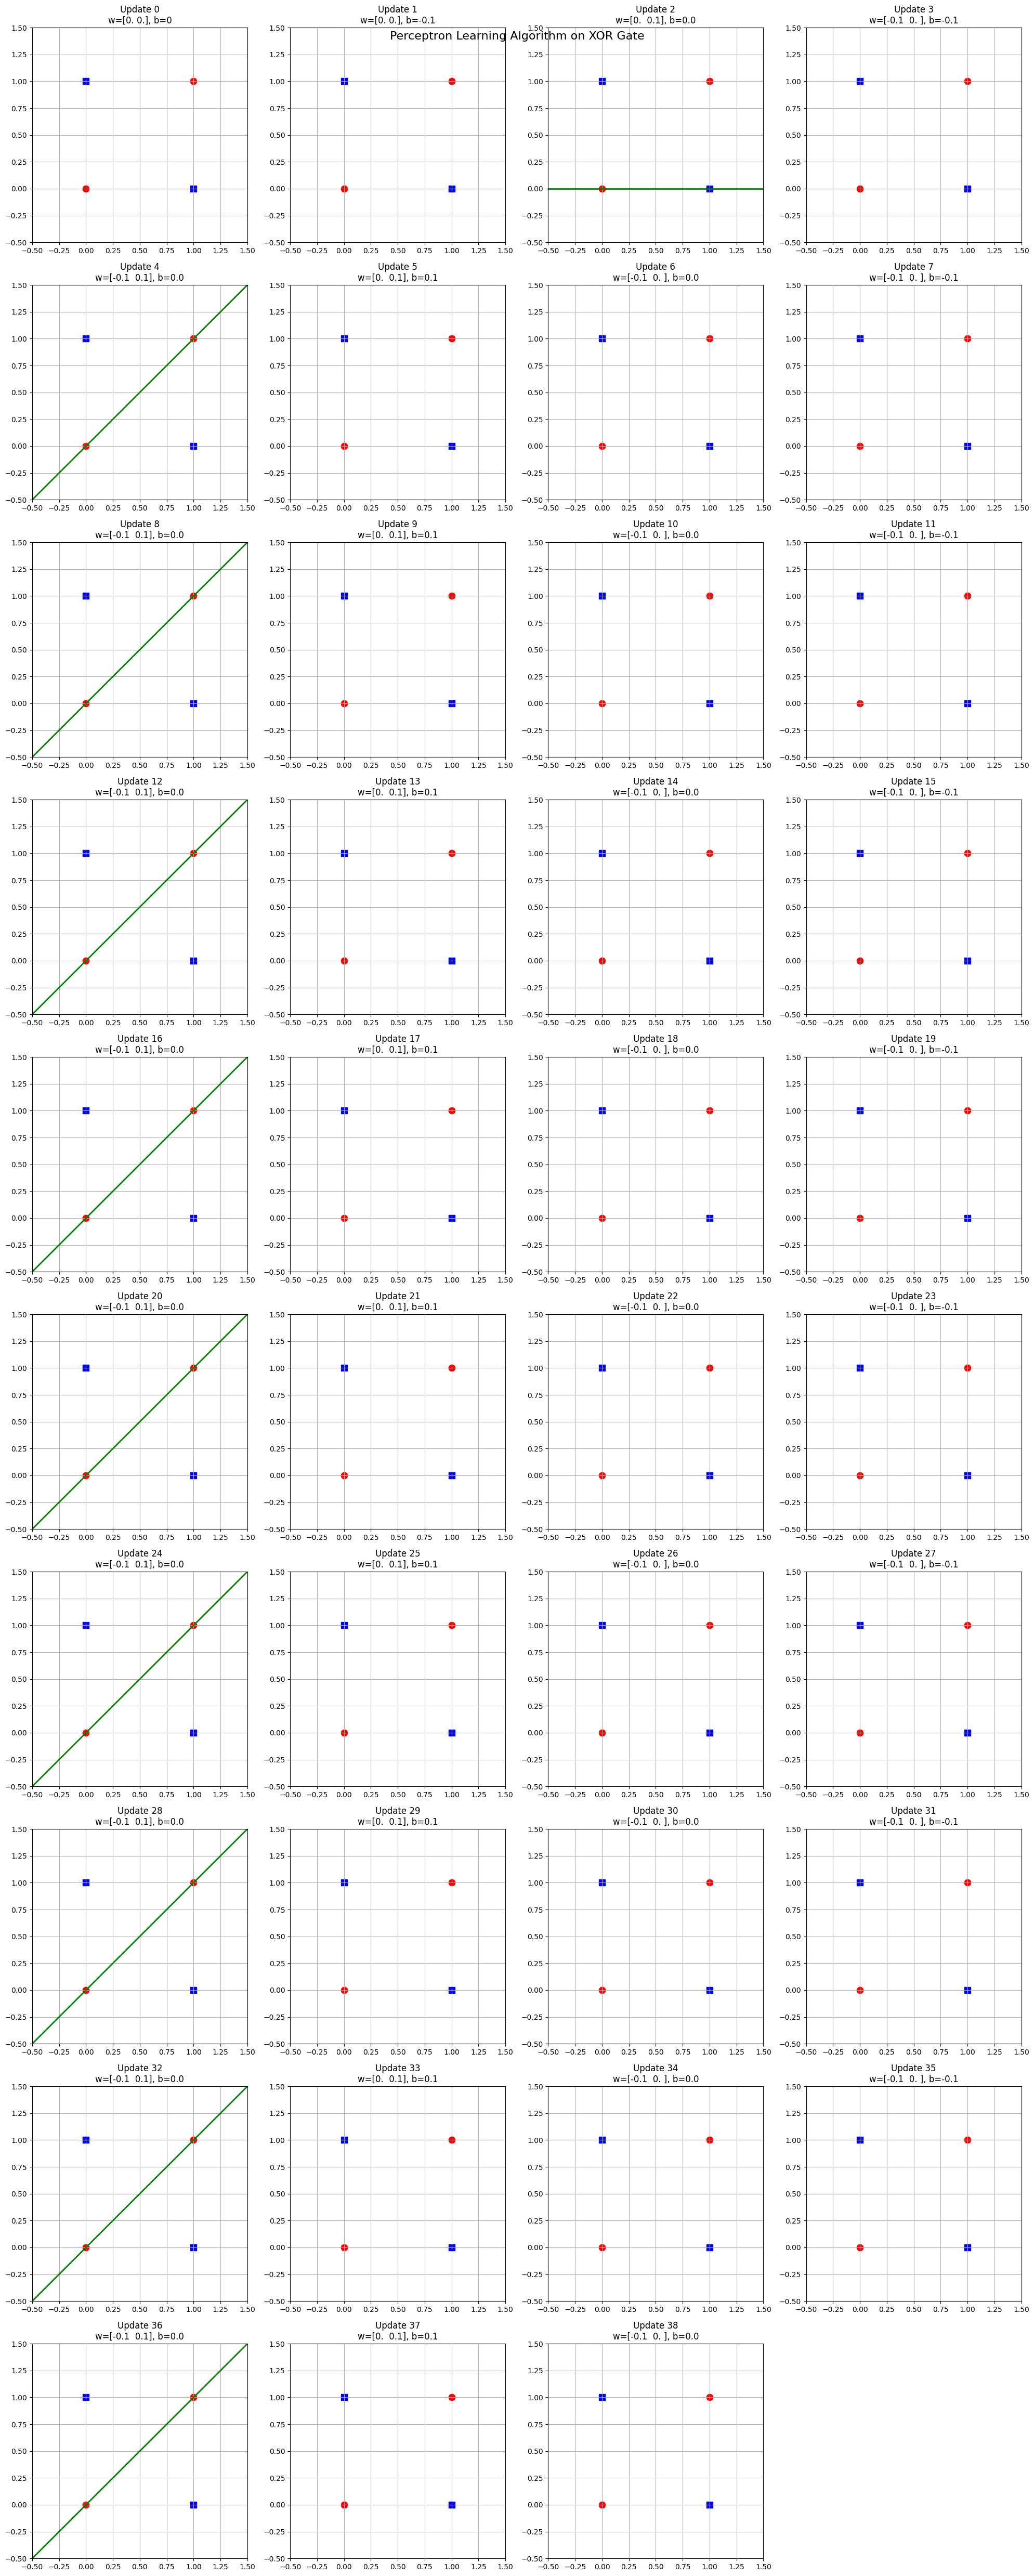

In [7]:
#additional task
import numpy as np
import matplotlib.pyplot as plt


X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])


w = np.zeros(2)
b = 0

learning_rate = 0.1
update_count = 0


all_boundaries = []


def step_function(x):
    return 1 if x >= 0 else 0


def save_boundary_data(w, b, iteration):
    all_boundaries.append((w.copy(), b, iteration))


print("Initial Weights")
print("w =", w)
print("b =", b)


save_boundary_data(w, b, 0)

max_epochs = 10

for epoch in range(max_epochs):

    print(f"\nEpoch {epoch + 1}")

    errors = 0

    for i in range(len(X)):

        net = np.dot(X[i], w) + b

        prediction = step_function(net)

        error = y[i] - prediction

        if error != 0:

            w = w + learning_rate * error * X[i]
            b = b + learning_rate * error

            update_count += 1
            errors += 1

            print(f"\nUpdate {update_count}")
            print("Input:", X[i])
            print("Target:", y[i])
            print("Prediction:", prediction)
            print("Error:", error)

            print("Updated Weights =", w)
            print("Updated Bias =", b)

            save_boundary_data(w, b, update_count)

    if errors == 0:
        print("\nConverged!")
        break

print("\nFinal Weights:", w)
print("Final Bias:", b)

print("\nObservation:")
print("XOR is not linearly separable.")
print("A single perceptron cannot find a decision boundary that correctly classify all XOR points.")
print("Hence the weights keep changing and the algorithm fails to converge.")


num_plots = len(all_boundaries)

cols = 4
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(5 * cols, 5 * rows)
)

axes = np.array(axes).reshape(-1)

for idx, (weights, bias, iteration) in enumerate(all_boundaries):

    ax = axes[idx]

    # Plot XOR points
    for i in range(len(X)):

        if y[i] == 0:
            ax.scatter(
                X[i][0],
                X[i][1],
                color='red',
                s=80,
                marker='o',
                label='Class 0' if i == 0 else ""
            )
        else:
            ax.scatter(
                X[i][0],
                X[i][1],
                color='blue',
                s=80,
                marker='s',
                label='Class 1' if i == 1 else ""
            )

    x_vals = np.linspace(-0.5, 1.5, 100)

    if abs(weights[1]) > 1e-10:
        y_vals = -(weights[0] * x_vals + bias) / weights[1]

        ax.plot(
            x_vals,
            y_vals,
            color='green',
            linewidth=2
        )

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    ax.set_title(
        f"Update {iteration}\n"
        f"w={np.round(weights,2)}, b={round(bias,2)}"
    )

    ax.grid(True)

for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle(
    "Perceptron Learning Algorithm on XOR Gate",
    fontsize=16
)

plt.tight_layout()
plt.show()